In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.shape
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing :-

# 1. Handle Missing Values

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
df.isna().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering 

In [7]:
# Year_Birth Convert to - Age (more convenient numerial value )

df["Age"] = df["Year_Birth"].max()- df["Year_Birth"]
df["Age"]


0       39
1       42
2       31
3       12
4       15
        ..
2235    29
2236    50
2237    15
2238    40
2239    42
Name: Age, Length: 2240, dtype: int64

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,39
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,42
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,31
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,12
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,15


In [9]:
# pandas.to_datetime() converts argument(s) to datetime.
# This function is essential for working with date and time data,
# especially when parsing strings or timestamps into Python's datetime64 format used in Pandas.
# Syntax
# pandas.to_datetime(arg, errors='raise', format=None, dayfirst=False, ...)

In [10]:
# Customer joining Date convert to:-  Numerial data:-

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days
df["Customer_Tenure_Days"]


0       663
1       113
2       312
3       139
4       161
       ... 
2235    381
2236     19
2237    155
2238    156
2239    622
Name: Customer_Tenure_Days, Length: 2240, dtype: int64

In [11]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,39,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,42,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,31,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,12,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,15,161


In [12]:
# Spending Combine 

df["Total_Spending"] = df["MntWines"]+ df["MntFruits"]+df["MntMeatProducts"]+ df["MntFishProducts"]+df["MntSweetProducts"]+ df["MntGoldProds"]
df["Total_Spending"] 


0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2240, dtype: int64

In [13]:
# Children Combine

df["Total_Children"] = df["Kidhome"]+ df["Teenhome"]
df["Total_Children"]


0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_Children, Length: 2240, dtype: int64

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,39,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,42,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,31,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,12,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,15,161,422,1


In [15]:
# Education

df["Education"].value_counts()

# convert to :- All Categories into :- 
# Undergraduate, Graduate , Postgraduate

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [16]:
df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate",
    "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Postgraduate",
    "PhD" : "Postgraduate"       
})

In [17]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [18]:
# Marital_Status

df["Marital_Status"].value_counts()

# Convert to:- All Categories into:- 
# New Column - Living_With .   Married & Together - Partner Head  &  balance  -  Alone head

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [19]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone",
    "Divorced" : "Alone",
    "Widow" : "Alone",
    "Absurd" : "Alone",
    "YOLO" : "Alone"
})

In [20]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop Columns

In [21]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,39,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,42,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,31,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,12,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,15,161,422,1,Partner


In [22]:
cols = ["ID", "Year_Birth" ,"Marital_Status","Kidhome", "Teenhome","MntWines","MntFruits" ,"MntMeatProducts","MntFishProducts",
      "MntSweetProducts", "MntGoldProds" ,"Dt_Customer"]

In [23]:
df_cleaned = df.drop(columns = cols)
df_cleaned.shape
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,39,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,42,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,31,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,12,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,15,161,422,1,Partner


# Outliers

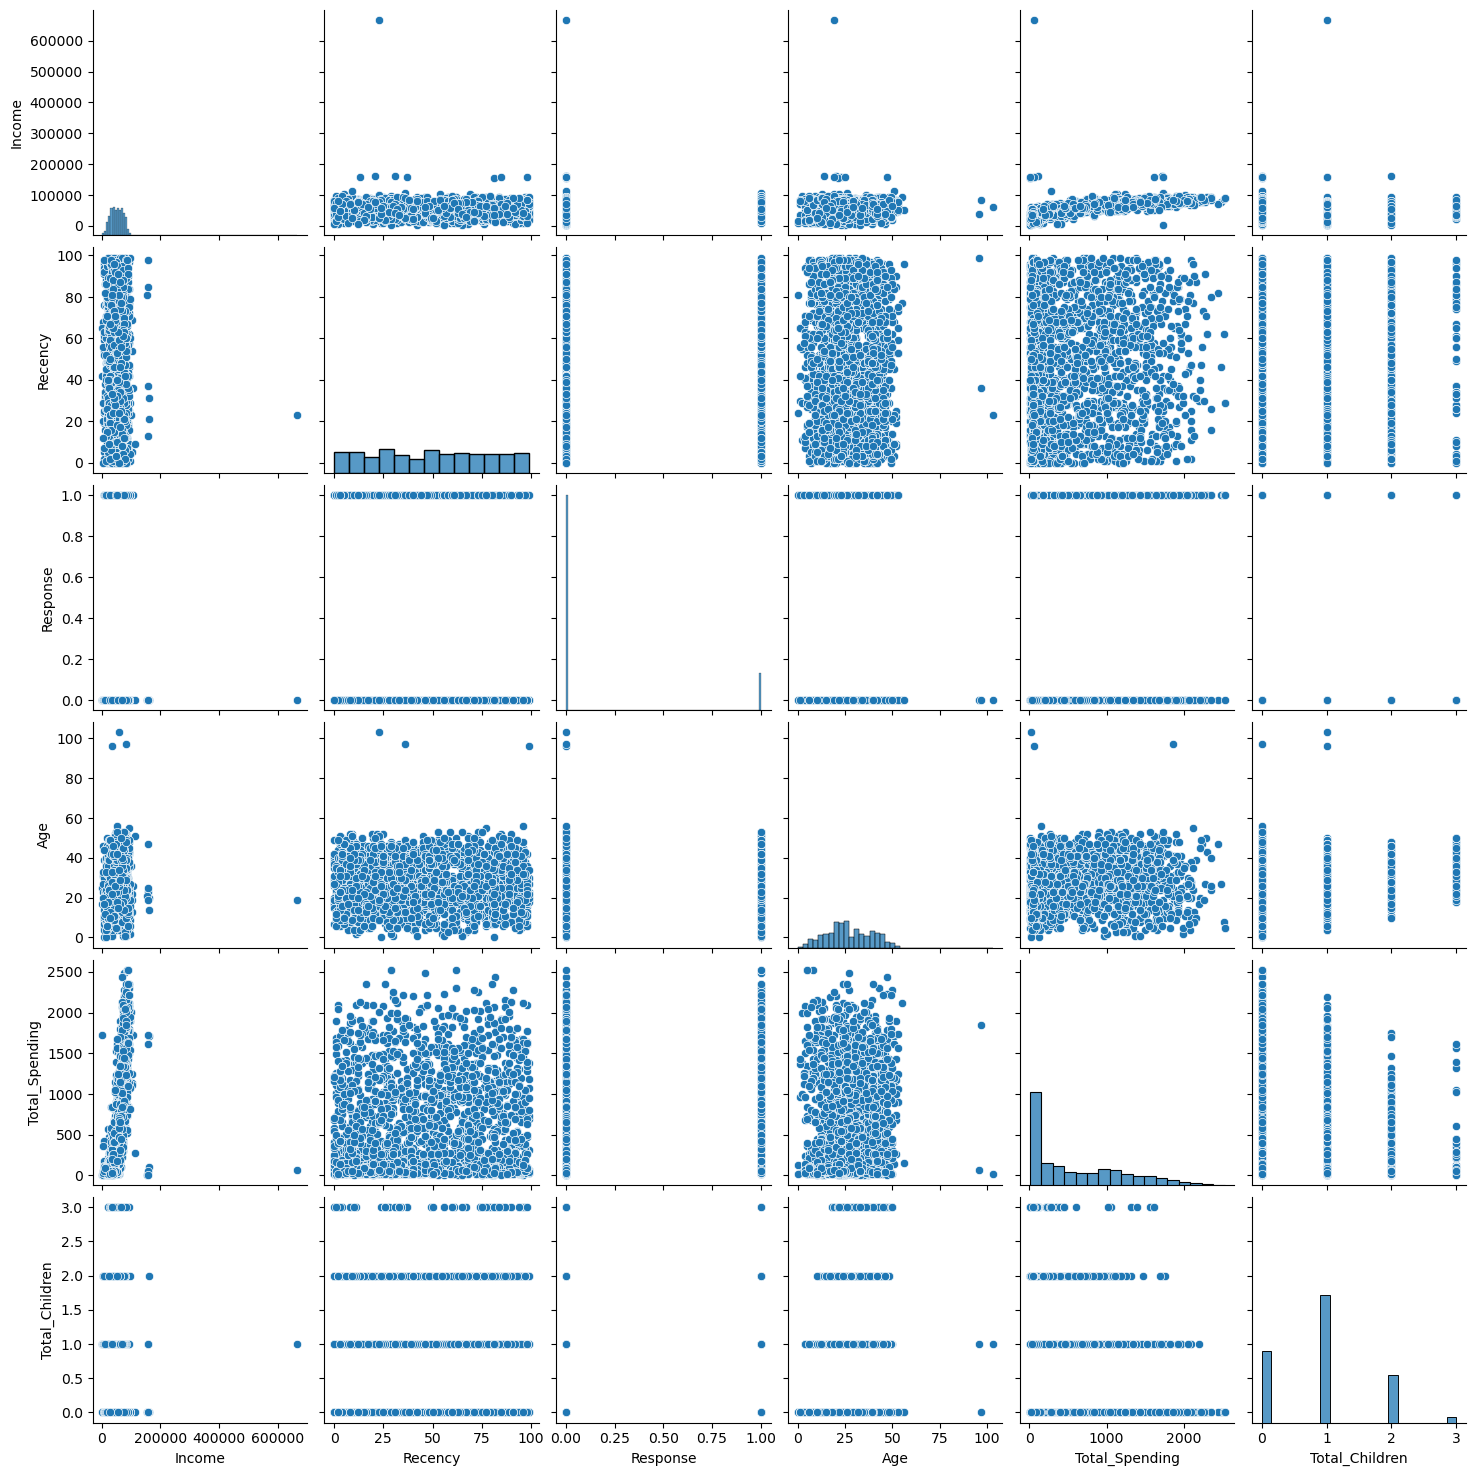

In [24]:
cols = ["Income", "Recency" , "Response", "Age", "Total_Spending", "Total_Children"]

# Relative Plots of some features - Pair Plots:-

sns.pairplot(df_cleaned[cols])

In [25]:
# Remove Outliers:-
print("data size with outliers :", len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600000)]

print("data size with outliers :", len(df_cleaned))

data size with outliers : 2240
data size with outliers : 2236


# Heatmap

In [26]:
corr_matrix = df_cleaned.select_dtypes("number").corr()
corr_matrix

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Figure size 800x800 with 0 Axes>

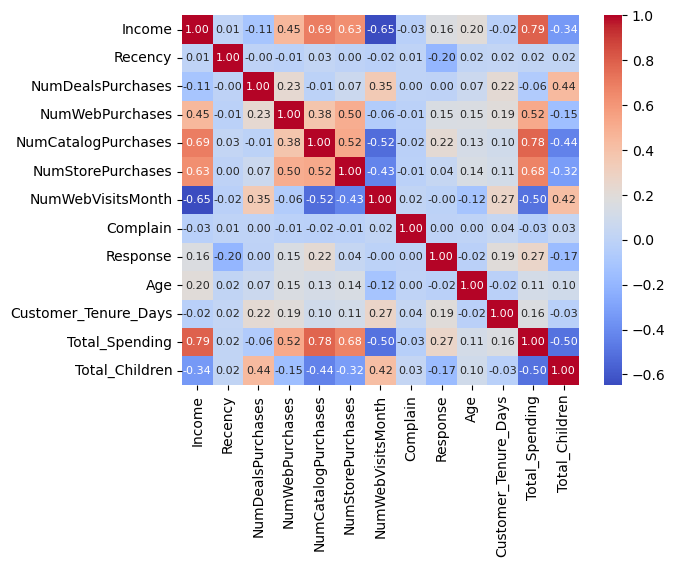

<Figure size 800x800 with 0 Axes>

In [27]:
# Plot Matrix
sns.heatmap(
    corr_matrix,
    annot = True,
    annot_kws = {"size": 8}, 
    fmt = ".2f",
    cmap = "coolwarm"
)
plt.figure(figsize = (8,8))

In [28]:
df_cleaned.shape

(2236, 15)

In [29]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,39,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,42,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,31,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,12,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,15,161,422,1,Partner


# Encoding 

In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_With"]
encoded_cols = ohe.fit_transform(df_cleaned[cat_cols])
encoded_array = encoded_cols.toarray() # In the form of array


In [32]:
encoded_cols_df = pd.DataFrame(encoded_array, columns = ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

In [33]:
encoded_cols_df .head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [34]:
# Now , append to the original Dataframe:-
df_cleaned_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), encoded_cols_df], axis = 1)

In [35]:
df_cleaned_encoded.shape
df_cleaned_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,39,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,42,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,31,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,12,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,15,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

In [61]:
scaler = StandardScaler()
X = df_cleaned_encoded
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visualize our data:-

In [38]:
X_scaled.shape

(2236, 18)

In [39]:
# 2D Visualize 

from sklearn.decomposition import PCA
pca = PCA(n_components = 2)

In [40]:
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[ 2.7087298 ,  2.39869224],
       [-1.76655338,  1.82575242],
       [ 1.81995208, -1.07430148],
       ...,
       [ 1.42793889,  1.81716429],
       [ 1.90073104, -1.4254157 ],
       [-0.96995283, -0.67250249]], shape=(2236, 2))

<Axes: >

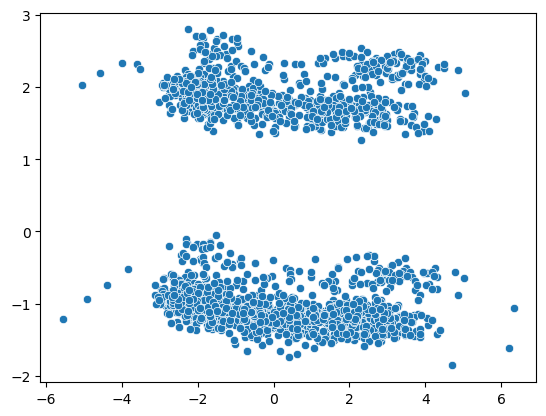

In [41]:
sns.scatterplot(
    x = X_pca[:,0],
    y = X_pca[:,1]
)
# plt.scatter(
#      x = X_pca[:,0],
#     y = X_pca[:,1]
    
# )

In [42]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [43]:
pca.components_

array([[ 4.32495231e-01, -4.77962864e-06, -6.61546905e-02,
         2.73378035e-01,  4.09002511e-01,  3.73746727e-01,
        -3.29131391e-01, -1.88136537e-02,  1.27218263e-01,
         9.66425138e-02,  3.59536437e-02,  4.50247045e-01,
        -2.80189921e-01,  7.79902112e-03,  4.64731872e-02,
        -8.33185400e-02,  2.20964364e-02, -2.20964364e-02],
       [-3.99368915e-02, -3.14842072e-02, -4.80235286e-02,
        -3.11617872e-02, -1.66793156e-02, -5.63142267e-02,
         3.49097435e-02,  4.98712690e-03,  1.95332864e-01,
        -4.90583971e-02,  3.66902408e-02, -8.27937537e-03,
        -5.21665505e-02,  5.44748637e-02, -4.65966398e-02,
        -1.44472010e-02,  6.85345977e-01, -6.85345977e-01]])

In [44]:
# 3D Visualize

pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[ 2.7087298 ,  2.39869224,  0.19587886],
       [-1.76655338,  1.82575242, -0.85552989],
       [ 1.81995208, -1.07430148, -1.27485084],
       ...,
       [ 1.42793889,  1.81716429, -1.87941234],
       [ 1.90073104, -1.4254157 ,  1.31005531],
       [-0.96995283, -0.67250249,  2.56404824]], shape=(2236, 3))

In [45]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

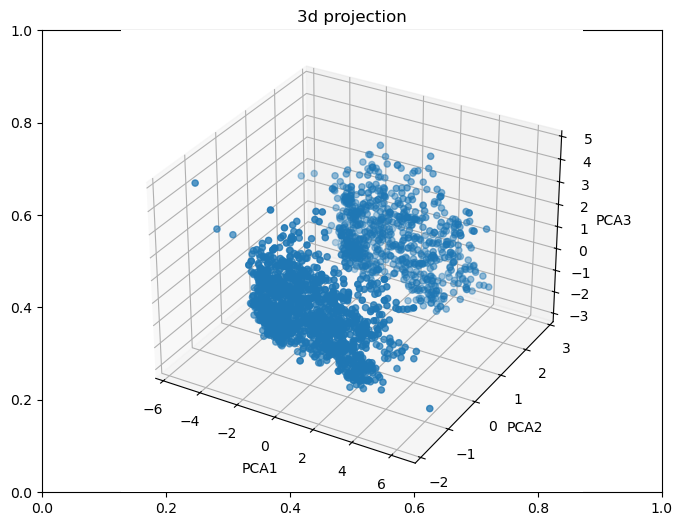

In [46]:
fig,ax = plt.subplots(figsize =(8,6))
ax = fig.add_subplot(projection = "3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2]    
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Analyze K value

# 1. Elbow Method

In [47]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42
    )
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    
wcss

[10760.84340175822,
 8830.288717243044,
 6650.969417658875,
 5006.161168001196,
 4396.308699108106,
 3857.6330644275718,
 3207.0576242216607,
 3025.2232554325824,
 2651.4429891061445]

In [48]:
kneelocator = KneeLocator(range(2,11), wcss, curve = "convex", direction = "decreasing")

In [49]:
kneelocator.knee
kneelocator.elbow

np.int64(5)

Text(0, 0.5, 'WCSS')

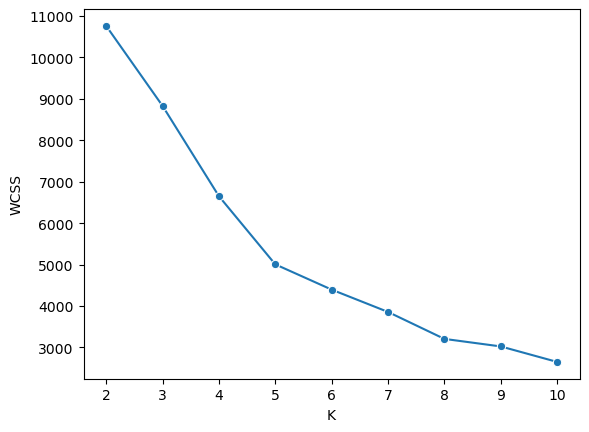

In [50]:
# Plot
fig,ax = plt.subplots()
sns.lineplot(
    x = range(2,11),
    y = wcss,
    marker = "o"
)
ax.set_xlabel("K")
ax.set_ylabel("WCSS")

# 2. Silhouette Score

In [51]:
from sklearn.metrics import silhouette_score
ss =[]
for k in range(2,11):
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42
    )
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    ss.append(score)
ss    

[0.37157939079771407,
 0.30768819274758036,
 0.3580996159598421,
 0.4000152147663747,
 0.39929183898600723,
 0.4026208740563286,
 0.40508588286950054,
 0.40118897046588675,
 0.4029117336489406]

Text(0, 0.5, 'Silhouette_Score')

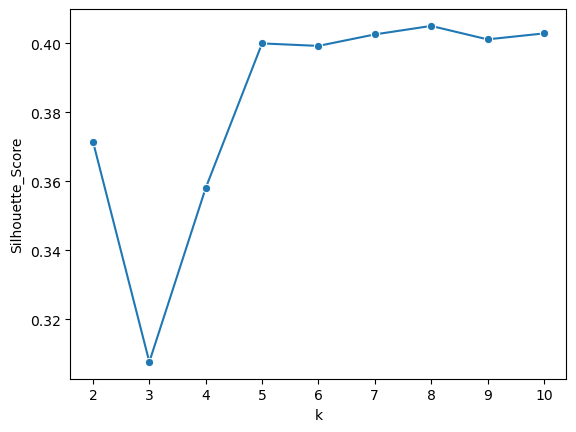

In [52]:
# Plot
fig,ax = plt.subplots()
sns.lineplot(
    x = range(2,11),
    y = ss,
    marker = "o"
)
ax.set_xlabel("k")
ax.set_ylabel("Silhouette_Score")

Text(0, 0.5, 'SS')

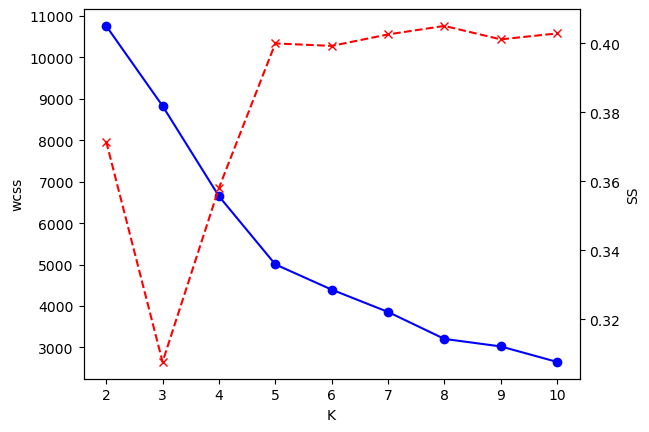

In [53]:
# Combine PLot:- with difference scale

# The code ax2 = ax1.twinx() is a Matplotlib function used to create a dual-axis plot. 
# It generates a secondary y-axis (ax2) that shares the exact same x-axis as 
# your original plot (ax1), but allows you to plot data on a completely independent y-scale.

k_range = range(2,11)

fig,ax = plt.subplots()
ax1 = ax.twinx()
ax.plot(k_range, wcss, marker = "o", color ="blue")
ax.set_xlabel("K")
ax.set_ylabel("wcss")
ax1.plot(k_range, ss, marker = "x", color = "red", linestyle = "--")
ax1.set_ylabel("SS")


# Apply Clustering Algorithms:-

In [54]:
# KMeans
kmeans = KMeans(
    n_clusters = 4,
    random_state = 42
    )
kmeans_labels = kmeans.fit_predict(X_pca)

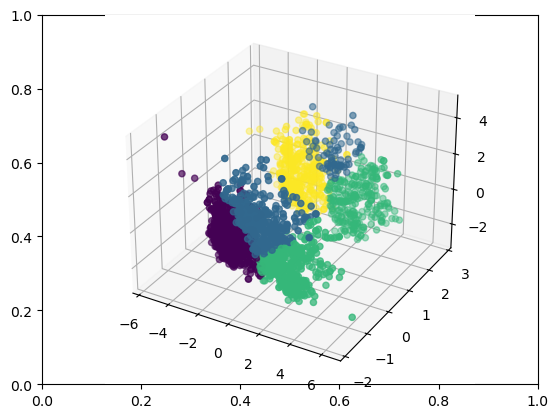

In [55]:
fig,ax = plt.subplots()
ax = fig.add_subplot(projection = "3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c = kmeans_labels
)

In [59]:
# Agglomerative 
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(
    n_clusters = 4,
    linkage = "ward"
)
agg_labels = agg_clf.fit_predict(X_pca)
agg_labels

array([3, 2, 1, ..., 3, 1, 0], shape=(2236,))

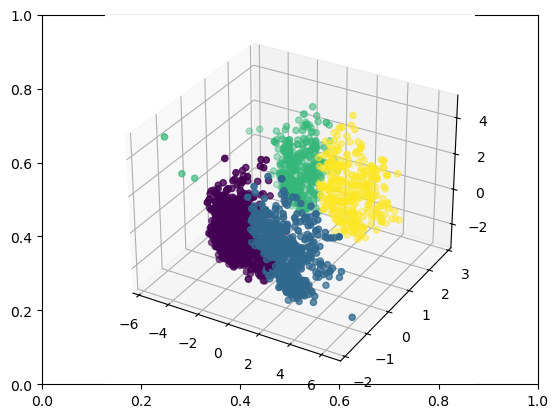

In [57]:
fig,ax = plt.subplots()
ax = fig.add_subplot(projection = "3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c = agg_labels
)

# Characterization of Clusters

In [62]:
# Add labels come from Agglomerative clustering in original data:-

df_cleaned_encoded["Labels"] = agg_labels # only in dataframe format , we can add new feature.

In [65]:
df_cleaned_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Labels
0,58138.0,58,3,8,10,4,7,0,1,39,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,42,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,31,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,12,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,15,161,422,1,0.0,1.0,0.0,0.0,1.0,0


In [120]:
df_cleaned_encoded["Labels"].value_counts()
data = df_cleaned_encoded["Labels"].value_counts().reset_index()
data

,Labels,count
0,0,905
1,1,534
2,2,444
3,3,353


<Axes: xlabel='Labels', ylabel='count'>

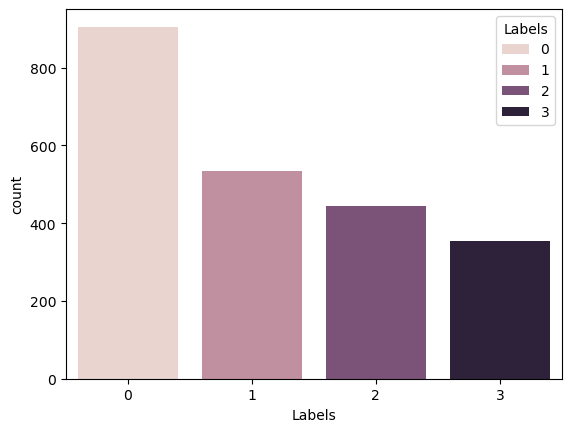

In [113]:
sns.barplot(data=data, x='Labels', y='ount',hue = "Labels")

<Axes: xlabel='Labels', ylabel='count'>

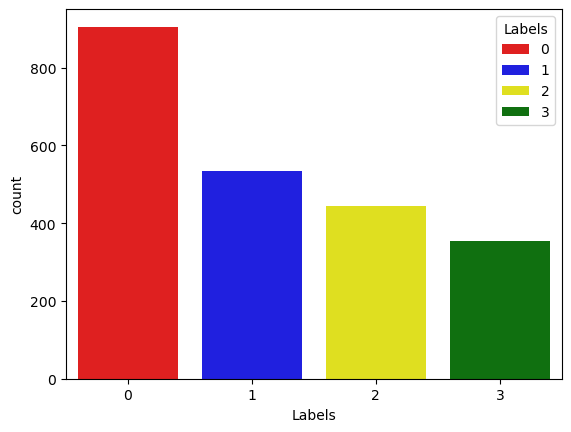

In [114]:
# No.of customers in each cluster

pal = ["red", "blue", "yellow", "green"]

sns.countplot(
    x = df_cleaned_encoded["Labels"],
    palette = pal,
    hue = df_cleaned_encoded["Labels"]
)

<Axes: xlabel='Total_Spending', ylabel='Income'>

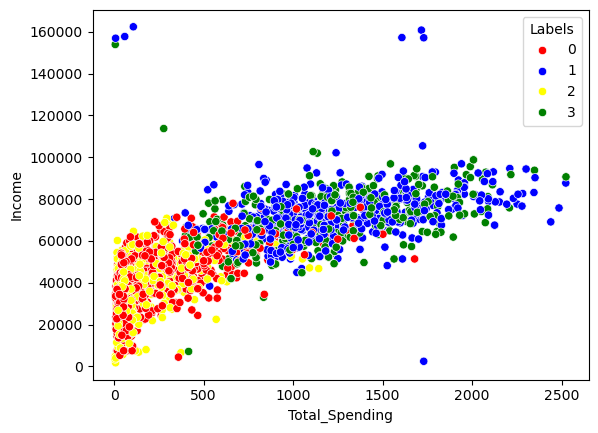

In [116]:
# Check Income and Spending Patterns - as per heatmap shows:- positive correlation

sns.scatterplot(
    data = df_cleaned_encoded,
    x  = "Total_Spending",
    y = "Income",
    hue = "Labels",
    palette = pal
)

# Cluster Summary

In [123]:
cluster_summary = df_cleaned_encoded.groupby("Labels").mean()
print(cluster_summary)

              Income    Recency  NumDealsPurchases  NumWebPurchases  \
Labels                                                                
0       39680.580110  48.914917           2.594475         3.153591   
1       72808.445693  49.202247           1.958801         5.687266   
2       36960.143018  48.319820           2.594595         2.713964   
3       70722.681303  50.504249           1.855524         5.790368   

        NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Labels                                                                        
0                  0.969061           4.143646           6.307182  0.011050   
1                  5.498127           8.659176           3.580524  0.005618   
2                  0.837838           3.623874           6.659910  0.011261   
3                  5.014164           8.430595           3.728045  0.005666   

        Response        Age  Customer_Tenure_Days  Total_Spending  \
Labels                       